Mounted at /content/drive
Top Features: ['dttl', 'sttl', 'sbytes', 'service', 'ct_srv_dst', 'swin', 'ct_dst_src_ltm', 'ct_dst_sport_ltm', 'tcprtt', 'dmean', 'dbytes', 'proto', 'smean', 'synack', 'ct_src_dport_ltm', 'ct_state_ttl', 'ct_srv_src']
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
5480/5480 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
    NU       VAC       TAC        F1  Training Time
0   16  0.847447  0.735510  0.690451      79.023097
1   32  0.840354  0.731666  0.691191      38.524991
2   64  0.855560  0.748279  0.712981      66.063837
3   96  0.855123  0.745473  0.685719      51.679175
4  128  0.860273  0.749237  0.705089      66.598835


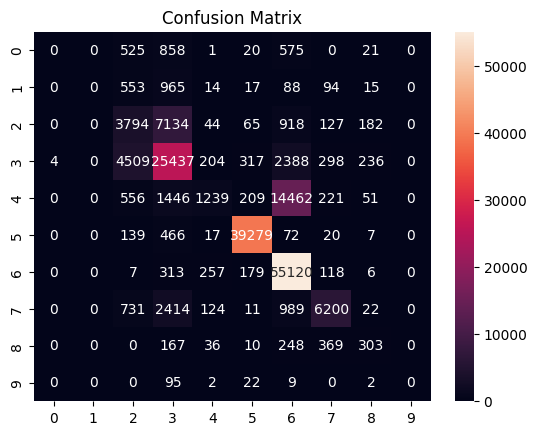

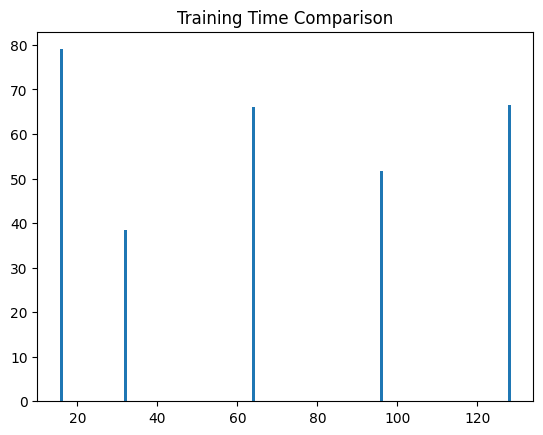

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6507/6507 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━

/tmp/ipykernel_28314/4243961631.py:251: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_flat[:50], feature_names=top_features)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-pack

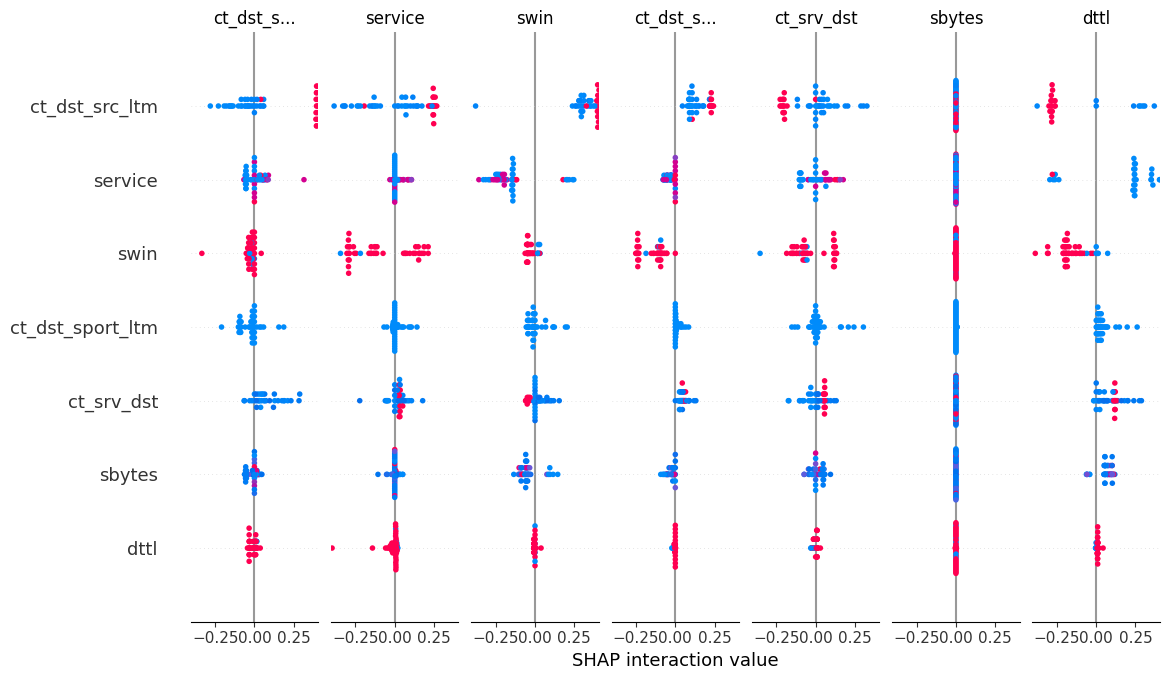

In [1]:
# =========================================================
# BIDIRECTIONAL RNN MULTICLASS IDS
# XGBoost + Attention + SHAP + Training Time
# NOVELTY: BiRNN
# =========================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import tensorflow as tf
import random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

# =========================================================
# SEED
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# =========================================================
# LOAD DATASET
# =========================================================
base_path = "/content/drive/MyDrive/UNSW_NB15/"

train_df = pd.read_csv(base_path + "UNSW_NB15_training-set.csv")
test_df  = pd.read_csv(base_path + "UNSW_NB15_testing-set.csv")

train_df.drop(columns=["id"], inplace=True)
test_df.drop(columns=["id"], inplace=True)

train_df["label"] = train_df["attack_cat"]
test_df["label"]  = test_df["attack_cat"]

train_df.drop(columns=["attack_cat"], inplace=True)
test_df.drop(columns=["attack_cat"], inplace=True)

train_df = train_df.dropna(subset=["label"])
test_df  = test_df.dropna(subset=["label"])

# =========================================================
# LABEL ENCODE
# =========================================================
cat_cols = ["proto","service","state"]

for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_df[col], test_df[col]]))
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# =========================================================
# SPLIT
# =========================================================
train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    stratify=train_df["label"],
    random_state=42
)

# =========================================================
# XGBOOST FEATURE SELECTION
# =========================================================
X_fs = train_df.drop("label", axis=1)
y_fs = train_df["label"].values

le_fs = LabelEncoder()
y_fs_enc = le_fs.fit_transform(y_fs)

xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1, eval_metric="mlogloss")
xgb.fit(X_fs, y_fs_enc)

feat_df = pd.DataFrame({
    "Feature": X_fs.columns,
    "FI": xgb.feature_importances_
}).sort_values("FI", ascending=False)

top_features = list(feat_df.head(17)["Feature"])
print("Top Features:", top_features)

# =========================================================
# DATA PREP
# =========================================================
X_train = train_df[top_features]
X_val   = val_df[top_features]
X_test  = test_df[top_features]

y_train = train_df["label"]
y_val   = val_df["label"]
y_test  = test_df["label"]

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)

y_train = to_categorical(y_train_enc, num_classes)
y_val   = to_categorical(y_val_enc, num_classes)
y_test  = to_categorical(y_test_enc, num_classes)

# =========================================================
# SCALING
# =========================================================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train = X_train.reshape(-1, 1, len(top_features))
X_val   = X_val.reshape(-1, 1, len(top_features))
X_test  = X_test.reshape(-1, 1, len(top_features))

# =========================================================
# ATTENTION LAYER
# =========================================================
class AttentionLayer(Layer):
    def build(self,input_shape):
        self.W=self.add_weight(shape=(input_shape[-1],1),initializer="normal")
        self.b=self.add_weight(shape=(input_shape[1],1),initializer="zeros")
        super().build(input_shape)

    def call(self,x):
        e=K.tanh(K.dot(x,self.W)+self.b)
        a=K.softmax(e,axis=1)
        output=x*a
        return K.sum(output,axis=1)

# =========================================================
# BUILD BiRNN MODEL (NOVELTY)
# =========================================================
def build_rnn(nu):

    inputs = Input(shape=(1,len(top_features)))

    x = Bidirectional(SimpleRNN(nu, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(SimpleRNN(nu, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(SimpleRNN(nu, return_sequences=True))(x)

    x = AttentionLayer()(x)

    x = Dense(nu//2, activation="relu")(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# =========================================================
# TRAIN LOOP
# =========================================================
NU_list = [16,32,64,96,128]
results = []

for nu in NU_list:

    model = build_rnn(nu)

    early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)

    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=256,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    Ts = time.time() - start
    VAC = max(history.history["val_accuracy"])

    preds = np.argmax(model.predict(X_test), axis=1)

    TAC = accuracy_score(y_test_enc, preds)
    F1  = f1_score(y_test_enc, preds, average="weighted")

    results.append([nu, VAC, TAC, F1, Ts])

# =========================================================
# RESULTS
# =========================================================
results_df = pd.DataFrame(results, columns=["NU","VAC","TAC","F1","Training Time"])
print(results_df)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test_enc, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# TRAINING TIME GRAPH
# =========================================================
plt.figure()
plt.bar(results_df["NU"], results_df["Training Time"])
plt.title("Training Time Comparison")
plt.show()

# =========================================================
# SHAP
# =========================================================
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[2])
X_test_flat  = X_test.reshape(X_test.shape[0], X_test.shape[2])

def predict_flat(x):
    x = x.reshape(x.shape[0], 1, x.shape[1])
    return model.predict(x)

explainer = shap.KernelExplainer(predict_flat, X_train_flat[:100])
shap_values = explainer.shap_values(X_test_flat[:50])

shap.summary_plot(shap_values, X_test_flat[:50], feature_names=top_features)